# Task 4: Custom Optimizers (SGD, RMSprop, Adam) from Scratch

Simple step-by-step update rules for weight optimization using PyTorch tensors.

In [1]:
import torch
import matplotlib.pyplot as plt

### 1. Minimize Quadratic Loss Function: $Loss = w^2$

In [2]:
# Compare 3 Optimizers starting from w = 5.0
opts = ['SGD', 'RMSprop', 'Adam']
history = {opt: [] for opt in opts}

for opt in opts:
    w = torch.tensor([5.0], requires_grad=True)
    lr = 0.1
    v, m = 0.0, 0.0  # Momentum / Adam memory

    for step in range(30):
        history[opt].append(w.item())
        loss = w ** 2
        loss.backward()
        grad = w.grad.item()

        with torch.no_grad():
            if opt == 'SGD':
                w -= lr * grad
            elif opt == 'RMSprop':
                v = 0.9 * v + 0.1 * (grad ** 2)
                w -= lr * grad / ((v ** 0.5) + 1e-8)
            elif opt == 'Adam':
                m = 0.9 * m + 0.1 * grad
                v = 0.99 * v + 0.01 * (grad ** 2)
                w -= lr * m / ((v ** 0.5) + 1e-8)
        w.grad.zero_()

### 2. Plot Convergence Speed

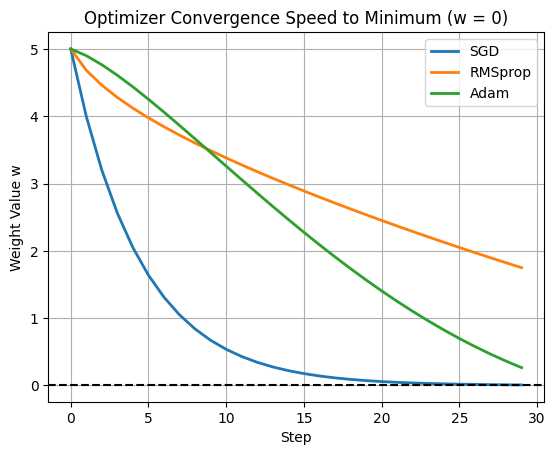

In [3]:
for opt, vals in history.items():
    plt.plot(vals, label=opt, lw=2)

plt.axhline(0, color='black', linestyle='--')
plt.title('Optimizer Convergence Speed to Minimum (w = 0)')
plt.xlabel('Step')
plt.ylabel('Weight Value w')
plt.legend()
plt.grid(True)
plt.show()